In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
df = pd.read_csv('/content/AIML Dataset.csv')

In [56]:
df.sample(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
1056114,96,TRANSFER,302346.21,C1582996754,27804.00,0.00,C562033251,269028.30,571374.52,0.0,0.0
860007,42,CASH_IN,397927.57,C669891072,78221.00,476148.57,C229276446,21353.99,0.00,0.0,0.0
1677127,159,TRANSFER,1503500.61,C1304306946,0.00,0.00,C1319409095,3958176.52,5461677.13,0.0,0.0
67108,9,PAYMENT,28434.17,C1561990696,1685640.59,1657206.42,M1824345774,0.00,0.00,0.0,0.0
1177008,132,CASH_OUT,21512.32,C1882248632,0.00,0.00,C334166178,76235.69,97748.01,0.0,0.0
1389597,139,PAYMENT,9604.00,C1026634451,436230.00,426626.00,M1823216143,0.00,0.00,0.0,0.0
723301,37,CASH_IN,12625.27,C651648954,100950.00,113575.27,C932315592,0.00,0.00,0.0,0.0
1792880,162,TRANSFER,531395.85,C274106816,15551.00,0.00,C5902211,639777.53,1171173.38,0.0,0.0
1193605,132,PAYMENT,9507.66,C699532757,444901.98,435394.32,M108585563,0.00,0.00,0.0,0.0
1168705,132,PAYMENT,4370.82,C339519954,0.00,0.00,M1896198062,0.00,0.00,0.0,0.0


In [57]:
df.isnull().sum()

,0
step,0
type,0
amount,1
nameOrig,1
oldbalanceOrg,1
newbalanceOrig,1
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


In [58]:
df.shape

(1888960, 11)

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888960 entries, 0 to 1888959
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
 10  isFlaggedFraud  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 158.5+ MB


In [60]:
df["isFraud"].value_counts()

,count
isFraud,
0.0,1887075
1.0,1884


In [61]:
df["isFlaggedFraud"].value_counts()

,count
isFlaggedFraud,
0.0,1888959


In [62]:
df["isFraud"].value_counts()[1]/df.shape[0]*100

np.float64(0.09973742165000847)

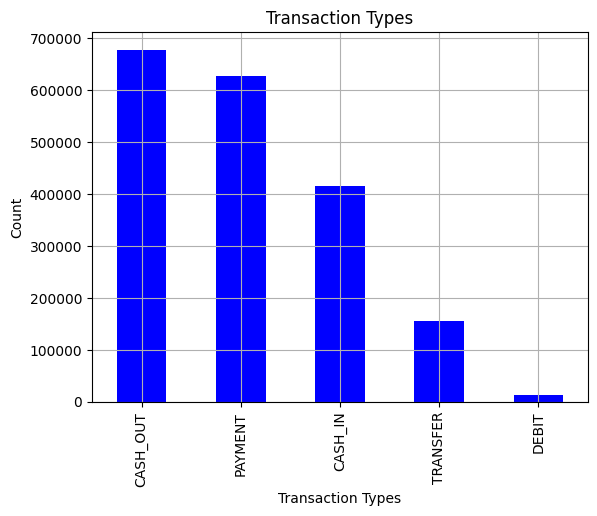

In [63]:
df["type"].value_counts().plot(kind='bar',title='Transaction Types',color='blue')
plt.xlabel('Transaction Types')
plt.ylabel('Count')
plt.grid()
plt.show()

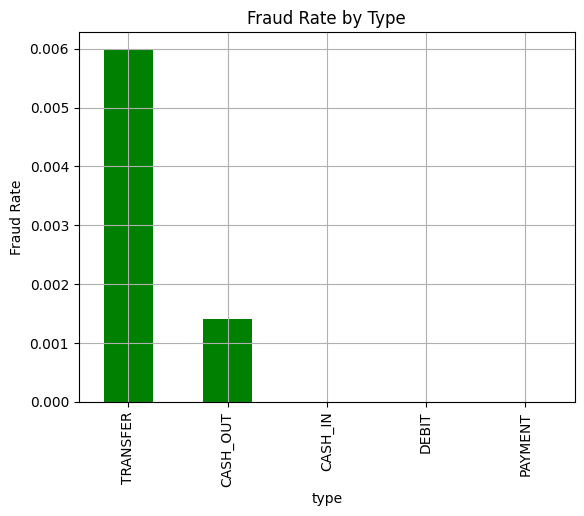

In [64]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar",title="Fraud Rate by Type",color="green")
plt.ylabel("Fraud Rate")
plt.grid()
plt.show()

In [65]:
df['amount'].describe().astype(int)

,amount
count,1888959
mean,161221
std,267199
min,0
25%,13281
50%,79112
75%,217011
max,10000000


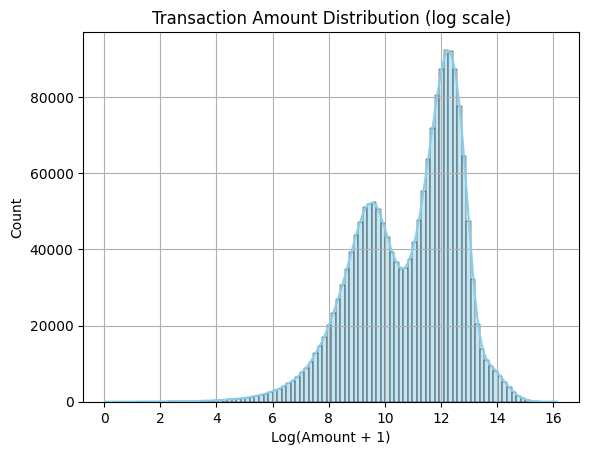

In [66]:
sns.histplot(np.log1p(df['amount']),bins=100, kde = True, color='skyblue')
plt.title("Transaction Amount Distribution (log scale)")
plt.xlabel("Log(Amount + 1)")
plt.grid()
plt.show()

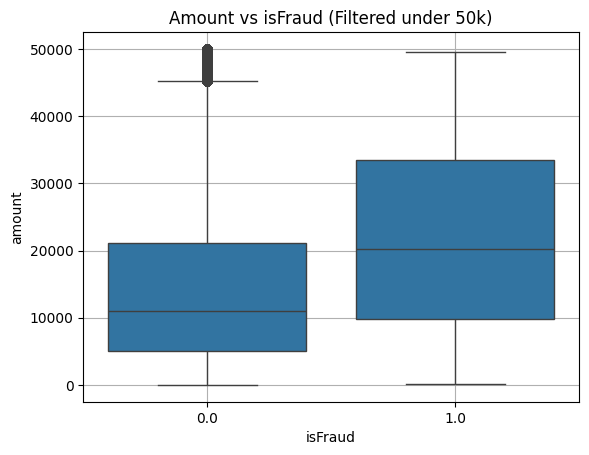

In [67]:
sns.boxplot(data=df[df["amount"]< 50000],x='isFraud',y='amount')
plt.title("Amount vs isFraud (Filtered under 50k)")
plt.grid()
plt.show()

In [68]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [69]:
df['balanceDiffOrig'] = df['oldbalanceOrg']- df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest']- df['oldbalanceDest']

In [70]:
(df['balanceDiffOrig']<0).sum()

np.int64(415623)

In [71]:
(df['balanceDiffDest']<0).sum()

np.int64(369905)

In [72]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,0.0


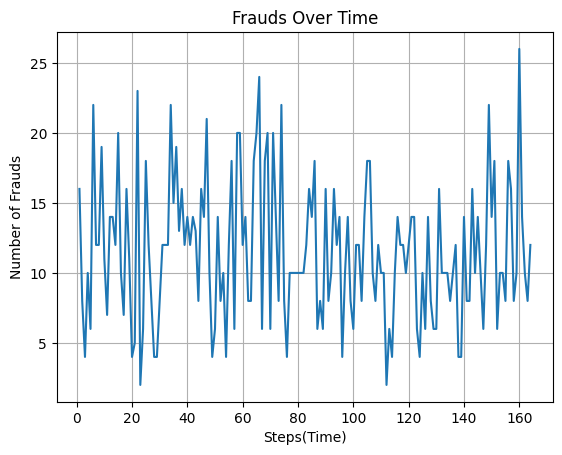

In [73]:
frauds_per_step = df[df['isFraud'] == 1]['step'].value_counts().sort_index()
plt.plot(frauds_per_step.index , frauds_per_step.values, label='Frauds per step')
plt.xlabel('Steps(Time)')
plt.ylabel('Number of Frauds')
plt.title('Frauds Over Time')
plt.grid(True)
plt.show()

In [74]:
df.drop(columns='step',inplace=True)

In [75]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,0.0


In [76]:
top_senders = df['nameOrig'].value_counts().head()

In [77]:
top_senders

,count
nameOrig,
C1999539787,3
C1540385828,2
C574606922,2
C1572898005,2
C1142808004,2


In [78]:
top_receivers = df['nameDest'].value_counts().head(10)

In [79]:
top_receivers

,count
nameDest,
C985934102,100
C1286084959,97
C665576141,94
C248609774,94
C1590550415,91
C2083562754,89
C1360767589,86
C977993101,86
C451111351,85


In [80]:
Fraud_users = df[df['isFraud'] == 1]['nameOrig'].value_counts().head()

In [81]:
Fraud_users

,count
nameOrig,
C741693784,1
C1305486145,1
C840083671,1
C1420196421,1
C2101527076,1


In [82]:
fraud_types = df[df['type'].isin(['TRANSFER','CASH_OUT'])]

In [83]:
fraud_types['type'].value_counts()

,count
type,
CASH_OUT,677949
TRANSFER,156326


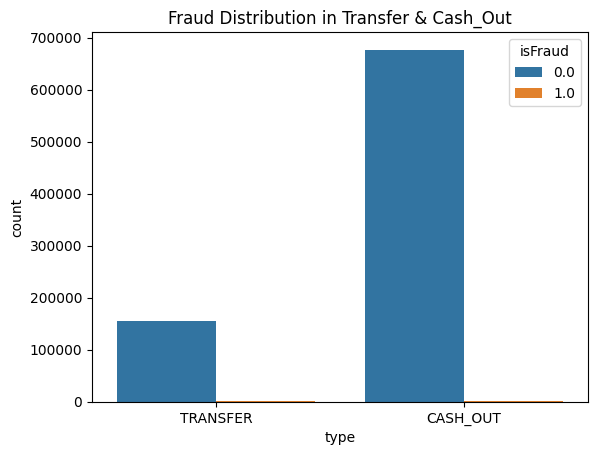

In [84]:
sns.countplot(data=fraud_types, x='type', hue='isFraud')
plt.title("Fraud Distribution in Transfer & Cash_Out")
plt.show()

In [85]:
corr = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']].corr()

In [86]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,0.001658,-0.003775,0.215193,0.310619,0.131837
oldbalanceOrg,0.001658,1.000000,0.999028,0.092640,0.063230,0.005145
newbalanceOrig,-0.003775,0.999028,1.000000,0.094619,0.062990,-0.008711
oldbalanceDest,0.215193,0.092640,0.094619,1.000000,0.983498,-0.006915
newbalanceDest,0.310619,0.063230,0.062990,0.983498,1.000000,0.000419
isFraud,0.131837,0.005145,-0.008711,-0.006915,0.000419,1.000000


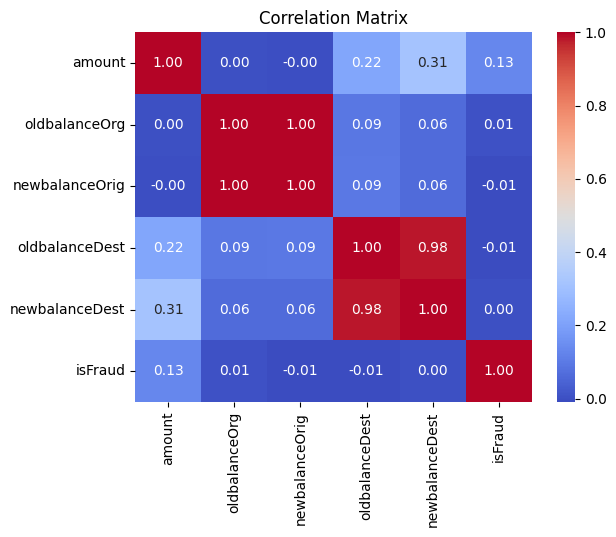

In [87]:
sns.heatmap(corr,annot=True,cmap = "coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [88]:
zero_after_transfer = df[
    (df['oldbalanceOrg'] > 0) &
    (df['newbalanceOrig'] == 0 ) &
    (df['type'].isin(['TRANSFER','CASH_OUT']))
 ]

In [89]:
len(zero_after_transfer)

354192

In [90]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1.0,0.0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1.0,0.0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0.0,0.0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0.0,0.0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0.0,0.0,10835.0,2712905.89


In [91]:
df['isFraud'].value_counts()

,count
isFraud,
0.0,1887075
1.0,1884


In [92]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [93]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0,11668.14,0.0


In [94]:
df_model = df.drop(["nameOrig","nameDest","isFlaggedFraud"],axis = 1)

In [95]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrig,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0.0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0.0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1.0,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1.0,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0.0,11668.14,0.0


In [96]:
categorical = ["type"]
numeric = ["amount","oldbalanceOrg","newbalanceOrig","oldbalanceDest"]

In [97]:
y = df_model["isFraud"]
X = df_model.drop("isFraud",axis = 1)

In [98]:
# Get indices where 'isFraud' is not NaN
non_nan_indices = y.dropna().index

# Filter X and y to exclude rows with NaN in 'isFraud'
X_filtered = X.loc[non_nan_indices]
y_filtered = y.loc[non_nan_indices]

X_train,X_test,y_train,y_test = train_test_split(X_filtered,y_filtered, test_size=0.3,stratify=y_filtered)

In [99]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numeric),
        ("cat",OneHotEncoder(drop="first"),categorical)
],
    remainder= "drop"
    )

In [100]:
pipeline = Pipeline([
    ("prep", preprocessor),
    ("clf",LogisticRegression(class_weight="balanced",max_iter=1000))
])

In [101]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [102]:
y_pred = pipeline.predict(X_test)

In [103]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

         0.0       0.94      1.00      0.97    533413
         1.0       0.97      0.02      0.03     33275

    accuracy                           0.94    566688
   macro avg       0.96      0.51      0.50    566688
weighted avg       0.94      0.94      0.92    566688



In [104]:
confusion_matrix(y_pred,y_test)

array([[533395,     18],
       [ 32728,    547]])

In [105]:
pipeline.score(X_test,y_test)*100

94.22151166073748

In [106]:
import joblib
joblib.dump(pipeline,"fraud_detection_pipeline.pkl")

['fraud_detection_pipeline.pkl']